# Train a Classifier!
____________________________________________________________________________________________________

For this tutorial, we will use the CIFAR10 dataset.
It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of
size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

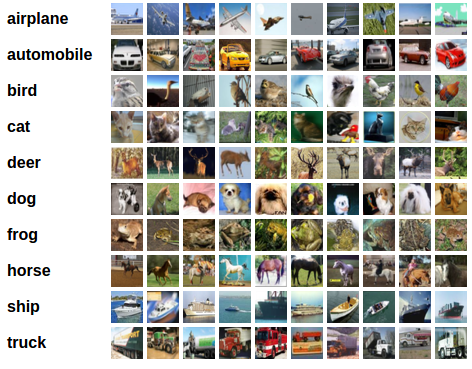

This is it. You are finally ready to:
We will do the following steps in order:

a. Load and normalizing the CIFAR10 training and test datasets using
   ``torchvision``

b. Define a Convolutional Neural Network

c. Define a loss function

d. Train the network on the training data

e. Test the network on the test data

## a. Loading and normalizing CIFAR10


Using ``torchvision``, it’s extremely easy to load CIFAR10.


In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

The CIFAR-10 dataset (via torchvision.datasets) gives you PIL images with pixel values in range [0, 255]
The output of torchvision datasets are PILImage images of range `[0, 255]`.

``transforms.ToTensor()`` converts the image to a PyTorch tensor and scales pixel values to [0, 1] by dividing by 255.

After ToTensor(), we usually apply normalization:
We transform them to Tensors of normalized range `[-1, 1]`.

**Why is this beneficial?**

🧠 1. **Faster and more stable training**

Neural networks converge faster when input features are centered around 0.

Reduces internal covariate shift, helping gradients flow better.

⚖️ 2. **Keeps all features in the same scale**

Especially important for models like CNNs and fully connected layers.

⚡ 3. **Better activation function behavior**

Functions like ReLU, Tanh, and Sigmoid behave better with zero-centered inputs.

## Normalize

Normalize a tensor image with mean and standard deviation. This transform does not support PIL Image. 

Given mean: (`mean[1],...,mean[n]`) and std: (`std[1],..,std[n]`) for `n` channels, this transform will normalize each channel of the input torch.

\begin{align}output[channel]=\frac{(input[channel] - mean[channel])}{std[channel]}\end{align}


mean (sequence) – Sequence of means for each channel.

std (sequence) – Sequence of standard deviations for each channel
## Example


mean=0.5

std=0.5
$$\text{normalized\_x} = \frac{x - \text{mean}}{\text{std}} = \frac{x - 0.5}{0.5} = 2x - 1$$


## Values
The values in `transforms.Normalize(mean, std)` are chosen based on the statistical distribution of pixel values in the dataset.

Here is how the two common approaches work:

### Method 1: Mathematical Mapping to $[-1, 1]$

*(Using `mean = (0.5, 0.5, 0.5)` and `std = (0.5, 0.5, 0.5)`)*

These values are chosen mathematically to shift the dynamic range without needing to calculate full dataset statistics:

1. `transforms.ToTensor()` converts RGB values from $[0, 255]$ to floating-point values in $[0.0, 1.0]$.
2. Using $0.5$ for both mean and standard deviation maps $[0.0, 1.0]$ directly onto $[-1.0, 1.0]$ via:

$$\text{Normalized Output} = \frac{\text{Pixel Value} - 0.5}{0.5}$$

* **Minimum pixel ($0.0$):** $\frac{0.0 - 0.5}{0.5} = -1.0$
* **Center pixel ($0.5$):** $\frac{0.5 - 0.5}{0.5} = 0.0$
* **Maximum pixel ($1.0$):** $\frac{1.0 - 0.5}{0.5} = 1.0$

This provides a simple, standardized baseline to zero-center the image data..
### Method 2: Dataset-Specific Statistics (Standardization)

*(Using `mean = (0.4914, 0.4822, 0.4465)` and `std = (0.2470, 0.2435, 0.2616)`)*

To achieve true **z-score standardization** ($\mu = 0, \sigma = 1$), the values are calculated directly across every single image in the dataset for each color channel (Red, Green, Blue):

1. **Calculate Channel Means ($\mu_R, \mu_G, \mu_B$):** Iterate over every pixel in all 50,000 CIFAR-10 training images, sum the values per channel, and divide by the total number of pixels.
2. **Calculate Channel Standard Deviations ($\sigma_R, \sigma_G, \sigma_B$):** Compute the standard deviation of pixel values for each channel across the entire training set.

For CIFAR-10, this calculation yields:

$$\text{Mean} = [0.4914, 0.4822, 0.4465]$$
$$\text{Std} = [0.2470, 0.2435, 0.2616]$$

When you pass these exact values to `transforms.Normalize(mean, std)`, the resulting dataset ends up with a mean of **$0.0$** and a standard deviation of **$1.0$** across each channel.


In [5]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=16, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=4,shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

**Note**

The ``num_workers`` parameter in a dataloader, like PyTorch's DataLoader or those in other libraries, determines the number of parallel subprocesses used to load data. A num_workers value of 0 means the data is loaded in the main process. Using a higher num_workers value (e.g., 1 or more) can accelerate training by allowing the GPU to process the current batch while worker processes load the next batch in parallel. However, the optimal num_workers value depends on your machine's CPU and GPU capabilities, so you should experiment to find the best balance for your system and dataset


**Let us show some of the training images, for fun.**


batch size: 16
color channels : 3
Image size:32x32


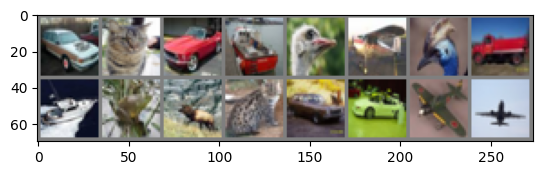

  car	   cat	   car	  ship	  bird	 plane	  bird	 truck	  ship	  frog	  deer	   cat	   car	   car	 plane	 plane	


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img /2  + 0.5     # unnormalize to [0,1]
    npimg = img.numpy() # change to numpy 
    plt.imshow(np.transpose(npimg, (1, 2, 0))) 
    plt.show()


# get some random training images and check the size
# The iter() method returns an iterator for the given argument.
data_iter = iter(trainloader)

# The next() function in Python is a built-in function used to retrieve the next item from an iterator.
images, labels = next(data_iter)

#images, labels = dataiter.next()
print('batch size:', images.size(0))
print('color channels :', images.size(1))
print('Image size:'+ str(images.size(2))+ 'x'+ str(images.size(3)))

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s\t' % classes[labels[j]] for j in range(16)))

## b. Define a Convolutional Neural Network

Copy the neural network from the Neural Networks section before and modify it to
take 3-channel (color) images, instead of 1-channel (black and white) images as it was defined.

### NOTE:
Pay attention to the in/out features dimensions, especially at the transition between a Convolution (Conv) and Fully connected (fc) linear layer

**Recap:**

Formula to get the output features size `h_out` of a 2D Conv layer given `h_in` (size features input), `k` (convolutional kernel size), `p` (zero padding), `D` (Dilation) and `s` (stride) (more details in [Conv2D documentation](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#conv2d))

\begin{align}h_{out}=\frac{ h_{in} + 2  \times p - D(k-1) - 1}{s} + 1 \end{align}

as D = 1 (default value of dilation)

\begin{align}h_{out}=\frac{h_{in} + 2 \times p - k}{s} + 1 \end{align}

**Example**

input image: H= 32, W=32 , C=3 (RGB)

Kernal Size: 5

Padding: 0

Stide: 1

output: (32 + 0 -5)/1  + 1= 28

Number of output channels = Number of filters

**Remember** that the feature size is divided by the MaxPool2d kernel size when passing through a 2D max pooling layer!
\begin{align} h_{out}=\frac{ h_{in}−k}{S}+1 \end{align}


_________________________________________________________________________________________________________________________

In [12]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # kernel=5x5 |input Tensor 3x32x32 (RGB image) | output:  tensor of 6x28x28 (6 feature maps of 28x28) | h_out = (32+0-5)/1 + 1 = 28
        self.conv1 = nn.Conv2d(3, 6, 5) 

        # kernel=2x2 | stride=2x2   
        # then the size of the output will be devided by 2
        # if input 6 feature maps of 28x28 then output:  6 feature maps of 14x14 | h_out = (28-2)/1+1 = 14
        # if input 6 feature maps of 10x10 then output:  16 feature maps of 5x5 | h_out = (10-2)/1+1 = 5
        self.pool = nn.MaxPool2d(2, 2) 

        # kernel=5x5 |input Tensor 6x14x14 | output: tensor of 16x10x10 (16 feature maps of 10x10) | h_out = (28-2)/1+1 = 14
        self.conv2 = nn.Conv2d(6, 16, 5) 

        #Flatten it to a vector: in_features = channels × height × width
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        #print("shape of x at input: ", x.shape)   
        x = self.pool(F.relu(self.conv1(x)))
        #print("shape of x after conv1: ", x.shape)
        x = self.pool(F.relu(self.conv2(x)))
        #print("shape of x after conv2: ", x.shape)
        x = x.view(-1, 16 * 5 * 5) # the size -1 is inferred from other dimensions
        #print("shape of x: ", x.shape)
        #print(x)
        x = F.relu(self.fc1(x))
        #print("shape of x after fc1: ", x.shape)
        x = F.relu(self.fc2(x))
        #print("shape of x after fc2: ", x.shape)
        x = self.fc3(x)
        return x


net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


## c. Define a Loss function and optimizer

Let's use a Classification Cross-Entropy loss and SGD with momentum.


In [8]:
import torch.optim as optim

#criterion = nn.MSELoss()
criterion = nn.CrossEntropyLoss() # default returns the mean of losses over batch
#criterion = nn.CrossEntropyLoss(reduction="none")
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

## d. Train the network

**This is when things start to get interesting!**

We simply have to loop over our data iterator, and feed the inputs to the
network and optimize. In this tutorial we will consider a small number of iterations over the dataset `n_epochs`


In [9]:
n_epochs=10

for epoch in range(n_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    # i → the batch index (0, 1, 2, …) , data → the actual batch (e.g. (inputs, labels)), The second argument (0) is the starting index.
    # enumerate(trainloader, 0) → starts counting at 0
    
    for i, data in enumerate(trainloader, 0): 
        #print("data: ", data)
        #print("data type: ", type(data))
        #print ("data size: ", len(data))
        #print ("data element type: ", type(data[0]))
        #print ("data element type: ", type(data[1]))
        
        #print ("data[0] size: ", data[0].size()) # images in the batch: size of one batch of images (Batch size,Channels, H, W)  
        #print ("data[1] size: ", data[1].size()) # lables in the batch:  Batch size (each image has one lable)
        
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        #print("loss:", loss)
       
        # print("Per-sample losses:", loss.detach().cpu().numpy())
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item() #.item() converts a 1-element tensor to int or float
        
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %(epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 1.734
[2,  2000] loss: 1.392
[3,  2000] loss: 1.278
[4,  2000] loss: 1.223
[5,  2000] loss: 1.169
[6,  2000] loss: 1.153
[7,  2000] loss: 1.137
[8,  2000] loss: 1.122
[9,  2000] loss: 1.110
[10,  2000] loss: 1.105
Finished Training


**Let's quickly save our trained model (see [here] (https://pytorch.org/docs/stable/notes/serialization.html) for more details on saving PyTorch models).**

In [15]:
PATH = './myNetcifar_net_10ephoc_lr=0.01.pth'
torch.save(net.state_dict(), PATH)

## e. Test the network on the test data


We have trained the network for `n_epochs` passes over the training dataset.
But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.



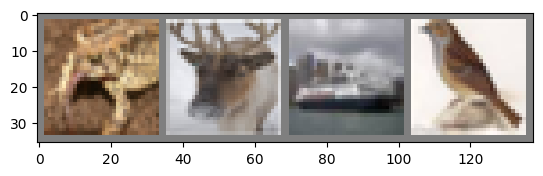

GroundTruth:   frog  deer  ship  bird


In [18]:
import matplotlib.pyplot as plt
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4))) # 4 is the batch sie in test loader

Next, let's load back in our saved model (note: saving and re-loading the model
wasn't necessary here, we only did it to illustrate how to do so):


In [19]:
PATH = './cifar_net_10ephoc_lr=0.01.pth'
trainednet = Net()
trainednet.load_state_dict(torch.load(PATH))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above are.

The outputs are energies for the 10 classes.
The higher the energy for a class, the more the network
thinks that the image is of the particular class.
So, let's get the index of the highest energy:


In [20]:
outputs = trainednet(images) 
# images: tensor containing the images of the batch shape = [batch size, channel, H, W]
# outputs: The outputs are energies for the 10 classes. : shape [B, num_classes]

print(outputs)
print("outputs.shape: " , outputs.shape)

#t: the maximum values along dim=1 (so the best score for each image). Shape [B].
# predicted: the indices of those max values → i.e. the predicted class labels. Shape [B].
t, predicted = torch.max(outputs, 1)

print(t)
print(predicted)
print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(4)))

tensor([[-1.6249e+00, -2.8120e+00,  1.0746e+00,  1.3654e+00,  3.6986e+00,
          2.0432e+00,  1.1702e+00,  2.1179e+00, -5.4441e+00, -1.5800e+00],
        [-4.1162e-01, -2.1305e+00,  7.7191e-01,  1.4886e+00,  7.5340e-01,
          1.6098e+00, -4.7802e-01, -1.4592e-03, -1.0043e+00, -1.4189e+00],
        [ 4.1642e+00,  2.1390e+00,  4.3918e-01, -2.5112e+00, -2.9519e+00,
         -4.9046e+00, -1.7022e+00, -5.6283e+00,  6.9668e+00,  1.6511e+00],
        [-3.2939e-01, -3.7240e+00,  2.8138e+00,  2.5531e+00, -1.3178e+00,
          1.9703e+00,  3.9831e-01, -6.6699e-01, -9.1858e-01, -3.0623e+00]],
       grad_fn=<AddmmBackward0>)
outputs.shape:  torch.Size([4, 10])
tensor([3.6986, 1.6098, 6.9668, 2.8138], grad_fn=<MaxBackward0>)
tensor([4, 5, 8, 2])
Predicted:   deer   dog  ship  bird


**Let us look at how the network performs on the whole dataset.**

In [16]:
correct = 0
total = 0
with torch.no_grad():  # torch.no_grad for TESTING
    for data in testloader:
        images, labels = data
        outputs = trainednet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))

Accuracy of the network on the 10000 test images: 56 %


That looks way better than chance, which is 10% accuracy (randomly picking
a class out of 10 classes).
Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:

In [50]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 28 %
Accuracy of   car : 63 %
Accuracy of  bird : 14 %
Accuracy of   cat : 26 %
Accuracy of  deer :  9 %
Accuracy of   dog : 48 %
Accuracy of  frog : 64 %
Accuracy of horse : 44 %
Accuracy of  ship : 35 %
Accuracy of truck : 58 %


## f. Continue Training

start from the trained model!
Load the saved model

In [12]:
PATH = './cifar_net_10ephoc_lr=0.01.pth'
trainednet = Net()
trainednet.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [17]:
n_epochs=10

for epoch in range(n_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = trainednet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %(epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 1.077
[2,  2000] loss: 1.082
[3,  2000] loss: 1.081
[4,  2000] loss: 1.071
[5,  2000] loss: 1.085
[6,  2000] loss: 1.085
[7,  2000] loss: 1.077
[8,  2000] loss: 1.077
[9,  2000] loss: 1.079
[10,  2000] loss: 1.077
Finished Training



Okay, so what next?

How do we run these neural networks on the GPU?

### Training on GPU
----------------
Just like how you transfer a Tensor onto the GPU, you transfer the neural
net onto the GPU.

Let's first define our device as the first visible cuda device if we have
CUDA available:


In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cpu


The rest of this section assumes that ``device`` is a CUDA device.

Then these methods will recursively go over all modules and convert their
parameters and buffers to CUDA tensors:

.. code:: python

    net.to(device)


Remember that you will have to send the inputs and targets at every step
to the GPU too:

.. code:: python

        inputs, labels = data[0].to(device), data[1].to(device)

Why dont I notice MASSIVE speedup compared to CPU? Because your network
is really small.
